In [2]:
import numpy as np
import matplotlib.pyplot as plt




In [139]:
def simulate_direct_mrac(m_true=1.0, b_true=2.0, k_true=3.0,
                                         wn=2.0, zeta=0.7, gamma=10.0,
                                         T=10.0, dt=0.001, tau_d=0.05,
                                         measurement_interval=0.05,
                                         control_interval=1,
                                         r_func=None, plot=True):
    """
    Direct MRAC with:
    - position measurement at measurement_interval (e.g. 20Hz = 0.05s)
    - control input updated every control_interval (e.g. 1.0 s)
    
    Args:
        measurement_interval: time between measurements [s]
        control_interval: time between control updates [s]
        Other args same as previous function
    """

    t = np.arange(0, T, dt)
    n = len(t)

    # Reference trajectory
    if r_func is None:
        r = 4 * np.ones_like(t)
    else:
        r = np.array([r_func(ti) for ti in t])

    y = 0.0
    y_dot_est = 0.0
    ym, ym_dot = 0.0, 0.0
    theta = np.zeros(3)

    u = 0.0  # initialize control input

    # For tracking last measurement and control update times
    last_measurement_time = -measurement_interval
    last_control_time = -control_interval

    # Storage
    Y, Ym, R, Theta, U, E = [], [], [], [], [], []

    # Variables to store the last measured position for velocity estimation
    y_meas_prev = y
    y_meas = y

    for i in range(n):
        time = t[i]

        # Update reference model every step
        ymdotdot = -2 * zeta * wn * ym_dot - wn**2 * ym + wn**2 * r[i]
        ym_dot += ymdotdot * dt
        ym += ym_dot * dt

        # Sample measurement if it's time
        if time - last_measurement_time >= measurement_interval:
            y_meas_prev = y_meas
            y_meas = y  # position measurement at current time

            # Estimate velocity by difference (finite difference)
            y_dot_est = (y_meas - y_meas_prev) / measurement_interval

            last_measurement_time = time

            # Update adaptation law using measurement phi vector
            phi = np.array([y_meas, y_dot_est, r[i]])
            e = y_meas - ym

            theta_dot = -gamma * e * phi
            theta += theta_dot * dt #Not entirely sure about this one if its dt or not
        else:
            # No new measurement; keep previous error and phi for adaptation frozen
            e = y_meas - ym

        # Update control input if control interval elapsed
        if time - last_control_time >= control_interval:
            # Form regression vector for control based on latest estimates
            phi_control = np.array([y_meas, y_dot_est, r[i]])
            u_unsat = np.dot(theta, phi_control)
            u = np.clip(u_unsat, 0, 60)
            last_control_time = time

        # True system dynamics update using current control u
        yddot = (u - b_true * y_dot_est - k_true * y) / m_true
        y_dot_true = y_dot_est + yddot * dt
        y += y_dot_true * dt

        # Store data
        Y.append(y)
        Ym.append(ym)
        R.append(r[i])
        #U = th1*y + th2*yd + th3*r
        #where y is position, yd is velocity, and r is reference
        #y and yd feedback, th1 is like proportional and th2 is like damping
        #Theta estimated from error between model and actual
        Theta.append(theta.copy())
        U.append(u)
        E.append(e)

    # Convert to arrays
    Y, Ym, R, Theta, U, E = map(np.array, [Y, Ym, R, Theta, U, E])

    if plot:
        plt.figure(figsize=(10,8))

        plt.subplot(3,1,1)
        plt.plot(t, R, 'k--', label='Desired r(t)')
        plt.plot(t, Y, 'b', label='Actual y(t)')
        plt.plot(t, Ym, 'r--', label='Model y_m(t)')
        plt.legend(); plt.grid(); plt.ylabel('Position')

        plt.subplot(3,1,2)
        plt.plot(t, U, 'r')
        plt.grid(); plt.ylabel('Control Input u(t)')

        plt.subplot(3,1,3)
        plt.plot(t, Theta)
        plt.grid(); plt.ylabel('Parameter Estimates θ')
        plt.legend(['θ₁','θ₂','θ₃']); plt.xlabel('Time (s)')
        plt.tight_layout()
        plt.show()

    return {
        't': t, 'y': Y, 'r': R, 'ym': Ym,
        'theta': Theta, 'u': U, 'error': E
    }

6.666666666666667


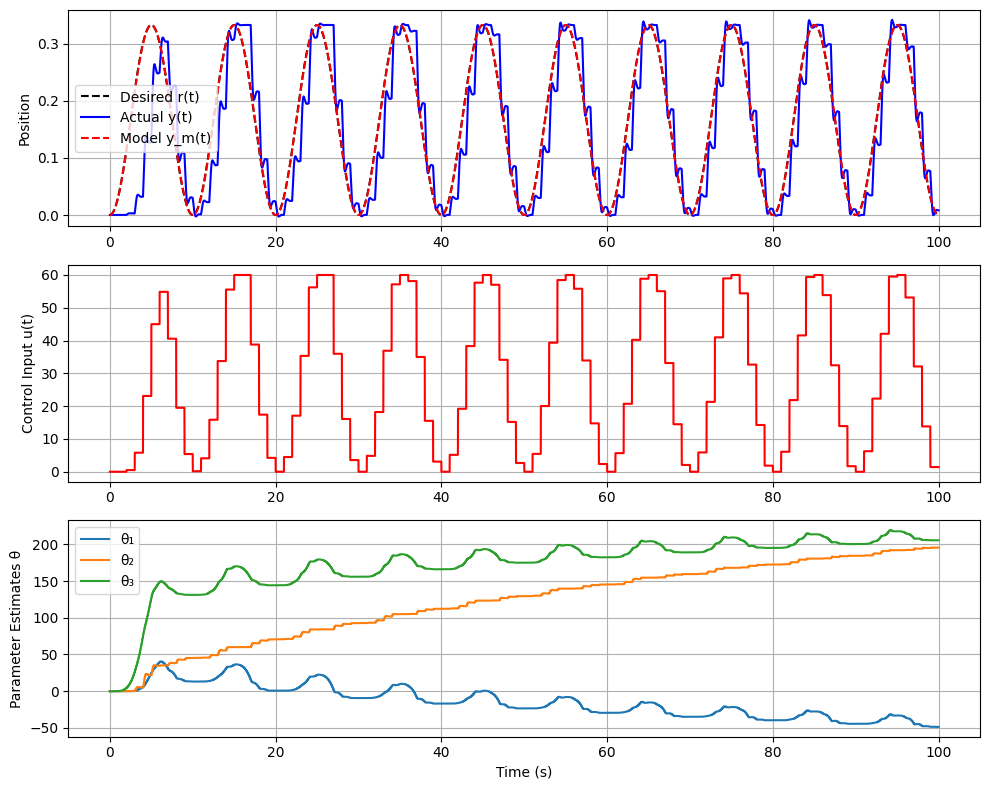

In [140]:
r_func = lambda t: (2 * -np.cos(2 * np.pi * 0.1 * t) + 2)/12 
#r_func = lambda t: np.clip(t/100,0,3/12) - np.clip(t/200,0,1/12)

zeta = .6
Ts = 1
wn = 4.0 / (zeta * Ts)
print(wn)

#lbf per inch - lbf per foot
result = simulate_direct_mrac(
    m_true=.05, b_true=1.5*12, k_true=15.0*12,
    wn=50.0, zeta=.6, gamma=40000, T=100, r_func=r_func
)